<a href="https://colab.research.google.com/github/MGentieu/dl_project/blob/main/starters/od-project-starter/od-project/notebooks/yolo_coco128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection Starter — Colab

# M1 — Problem Scoping & Data Validation



### Problem Statement
L’objectif de ce projet est d’entraîner un modèle YOLOv8n pour détecter les objets dans des images issues du dataset COCO128.  
L’entrée du modèle est une image RGB de taille variable, et la sortie consiste en des bounding boxes + labels + scores de confiance.

### Model Inputs
- Image RGB (normalisée), dimension variable, redimensionnée à 640×640.

### Model Outputs
- Liste de bounding boxes `(x1, y1, x2, y2)`
- Classe prédite (0–79)
- Score de confiance (0–1)

### Evaluation Metrics
- **map50**
- **map**
- **Precision**
- **Recall**

### Dataset Split
COCO128 utilise un split standard :
- 118 images pour l’entraînement
- 10 images pour la validation  
*(aucune modification n’est requise pour ce projet)*


## Data Card – COCO128 Dataset



### 1. Dataset Summary
COCO128 est une version réduite du dataset COCO (Common Objects in Context), comprenant **128 images** annotées pour la détection d’objets.  
Il reprend les **80 classes COCO** et inclut pour chaque objet une annotation de bounding box.

Ce dataset est principalement utilisé pour :
- valider rapidement un pipeline de détection d’objets,
- tester un modèle ou une configuration,
- réaliser des expériences légères sur GPU limité (ex : Colab T4).

Il n’est **pas conçu** pour entraîner un modèle performant, mais pour servir de **sandbox éducatif ou technique**.

---

### 2. Motivation
Le dataset COCO complet contient 118 000 images d’entraînement, ce qui le rend coûteux à utiliser pour :
- les tutoriels,
- les expérimentations rapides,
- les environnements à ressources limitées (Google Colab),
- les projets pédagogiques.

COCO128 répond au besoin d’un dataset :
- **léger**,  
- **varié**,  
- **rapide à charger**,  
- **compatible COCO**,  
tout en conservant la diversité des scènes du dataset original.

---

### 3. Dataset Composition

- **Nombre d’images :** 128  
- **Nombre de classes :** 80  
- **Classes :** mêmes étiquettes COCO (ex : person, car, dog, cat, bicycle, airplane…)  
- **Type d’annotations :** bounding boxes + catégories  
- **Format :** dossiers `images/` et `labels/` au format YOLO, dérivés du format COCO JSON  
- **Scènes représentées :**  
  - espaces urbains  
  - scènes intérieures  
  - sports  
  - animaux  
  - véhicules  
  - objets du quotidien  

**Distribution des classes :** Extrêmement déséquilibrée. Certaines classes apparaissent 10+ fois, d’autres 1 seule fois, certaines pas du tout dans la validation.

---

### 4. Data Collection Process
Les images proviennent du dataset COCO original (COCO 2017).  
Elles ont été sélectionnées de manière à illustrer différentes classes et scènes.  
Aucune nouvelle collecte n’a été effectuée.

Les annotations sont une version fidèle des annotations COCO, simplement converties au format YOLO.

---

### 5. Preprocessing

Les étapes standard lors de l’utilisation avec YOLOv8 sont :

- redimensionnement automatique (ex : 640×640)  
- normalisation des images  
- conversion en tenseurs PyTorch  
- data augmentation légère (flips, scales, color jitter) si activée  

Le dataset n’applique aucune transformation en amont : tout est géré par le framework de détection.

---

### 6. Applicability & Intended Use

**Recommandé pour :**
- tests rapides d’un modèle YOLO  
- validation d’un pipeline machine learning  
- débug et smoke tests  
- projets éducatifs  
- ablation studies à faible coût  

**Non recommandé pour :**
- évaluer un modèle dans un contexte réel  
- entraîner un modèle haute performance  
- faire de l'analyse fine par classe (dataset trop petit)

---

### 7. Risks & Biases

- **Distribution très déséquilibrée :**  
  → certaines classes dominent complètement les résultats,  
  → d’autres classes sont quasi absentes → faible recall ou aucune détection.
  
- **Taille extrêmement réduite :**  
  → risque de surapprentissage,  
  → résultats peu généralisables.

- **Variabilité limitée :**  
  → les scènes ne couvrent pas la diversité complète de COCO.

Ce dataset **ne doit jamais être utilisé** pour évaluer la robustesse réelle d’un modèle.

---

### 8. Limitations

- Seulement **128 images** : insuffisant pour un entraînement complet.  
- Certaines classes n’apparaissent qu’une seule fois → mAP très variable.  
- Les performances ne sont pas représentatives de l’utilisation réelle de YOLO.  
- Le dataset ne permet pas d’étudier des phénomènes complexes (occlusion, petites instances, clutter).


## Ouverture du dataset et installation

### Connexion à github



Pour github : à exécuter dans le terminal de colab

git clone https://github.com/MGentieu/dl_project.git

### Step 0 — Confirm the GPU is ready
Run the next cell. You should see GPU name and memory. If you see `nvidia-smi unavailable`, the runtime is still on CPU—return to the checklist, enable GPU, then rerun this cell.

In [42]:
!nvidia-smi || echo "nvidia-smi unavailable (CPU runtime)"


Tue Dec  2 19:24:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P0             29W /   70W |     214MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 1 — Point the notebook at the project folder
This cell ensures the current working directory is `od-project`.
If it raises a `FileNotFoundError`, confirm where you uploaded/cloned the folder and adjust the path before rerunning.

In [43]:
import os
import sys
from pathlib import Path

# The user has provided the explicit path to the project root.
PROJECT_ROOT = Path("/content/dl_project/starters/od-project-starter/od-project")

print(f"Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT")

# Validate structure
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"Missing src/ directory at {PROJECT_ROOT}")

# Setup Python path
os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")


Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT
Project root: /content/dl_project/starters/od-project-starter/od-project
Working directory: /content/dl_project/starters/od-project-starter/od-project


### Step 2 — Install the project requirements
Installs Ultralytics + supporting libraries from `requirements.txt`. First run downloads the YOLO packages, which may take a couple of minutes.
If installation fails (e.g., due to connectivity), rerun this cell before proceeding.

In [5]:
# Install project dependencies listed in requirements.txt
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.7 MB/s eta 0:00:00


In [8]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 125.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 131.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 109.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


CUDA available: True
CUDA device: Tesla T4


In [4]:
!pip install ultralytics --upgrade

# M2 — Baseline Model Implementation

Nous utilisons YOLOv8n comme modèle baseline.  
Avant tout entraînement, nous validons que :

1. Le modèle se charge correctement  
2. Un batch peut passer dans le modèle sans erreur  
3. L’entraînement démarre correctement  

### Step 3 — Run the smoke test
This loads the pretrained YOLO weights specified in the config and runs a single prediction on a sample image. It writes `outputs/smoke_metrics.json` so you know the toolkit is ready.
If you hit a download error, wait briefly and rerun the cell.

In [22]:
text = open("configs/yolo_coco128.yaml").read()
text = text.replace("device: auto", "device: 0")
open("configs/yolo_coco128.yaml", "w").write(text)

216

In [23]:
print(open("configs/yolo_coco128.yaml").read())

task: object_detection
seed: 42
output_dir: outputs

model:
  weights: yolov8n.pt

data:
  yaml: coco128.yaml
  imgsz: 640
  batch: 16

train:
  epochs: 5
  lr0: 0.01
  weight_decay: 0.0005
  patience: 20

device: 0



In [13]:
from src import smoke_check
import importlib
importlib.reload(smoke_check)

smoke_path = smoke_check.run_smoke("configs/yolo_coco128.yaml")
print(smoke_path.read_text())


{
  "num_boxes": 6,
  "mean_confidence": 0.6556,
  "imgsz": 640,
  "weights": "yolov8n.pt"
}


## 1. Review smoke-test output
- Confirm the previous cell printed a JSON block showing the number of detections and mean confidence.
- `outputs/smoke_metrics.json` should now appear in the file browser.
- Need only a quick environment check? Stop here. Ready to fine-tune? Continue to Section 2.
- If anything failed, read the message, fix the issue, and rerun the smoke cell before moving on.

## 2. Full training run


In [14]:
# Train the model using the default coco128 configuration.
# Ultralytics manages the training loop and saves weights to outputs/train/weights/.
!python src/train.py --config configs/yolo_coco128.yaml


Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained=True,

In [15]:
# Evaluate the best checkpoint on the validation split.
# Results (mAP, precision, recall) are saved to outputs/eval.json.
!python src/evaluate.py --config configs/yolo_coco128.yaml --ckpt outputs/train/weights/best.pt


Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1475.3±424.7 MB/s, size: 73.3 KB)
val: Scanning /content/dl_project/starters/od-project-starter/od-project/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 2.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.4it/s 2.3s
                   all        128        929      0.675      0.586      0.653      0.487
                person         61        254      0.805      0.677      0.771      0.547
               bicycle          3          6      0.481      0.333      0.385      0.292
                   car         12         46      0.721      0.217      0.287      0.186
            motorcycle          4          5      0.688      0.888      0.938 

# M3 — Optimization & Regularization

YOLOv8 inclut plusieurs techniques importantes de régularisation et d’optimisation :

### Regularization
- **Weight Decay = 0.0005** (évite le surapprentissage)
- **Data augmentation automatique** : flips, scaling, HSV jitter

### Learning Rate Scheduling
- **Cosine annealing scheduler** avec warmup progressif du LR

### Early Stopping
 Un mécanisme d’**early stopping** est configuré dans YOLO avec une certaine `patience`.
- Dans ce projet, nous avons limité l’entraînement à **5 epochs**, ce qui est suffisant pour COCO128 et compatible avec les contraintes de temps/ressources en environnement Colab.
- Le meilleur modèle est automatiquement sauvegardé sous `best.pt`

Ces mécanismes rendent le modèle stable malgré la petite taille du dataset COCO128.


### On affiche à présent les résultats obtenus et on analyse :

1. Affichage des métriques globales du modèle :

In [16]:
import json

with open("outputs/metrics.json", "r") as f:
    metrics = json.load(f)

metrics

{'run_dir': 'outputs/train',
 'best_weights': 'outputs/train/weights/best.pt',
 'metrics': {'map50': 0.652948919407326,
  'map': 0.48657843926128913,
  'precision': 0.6748354909492364,
  'recall': 0.5861194234374383}}

On coco128, le modèle atteint une map50 d’environ **0.652**, ce qui est correct pour un petit dataset de 128 images.  
La map plus stricte reste à **0.486**, indiquant que le modèle conserve une bonne qualité de localisation.  
La **précision (≈0.675)** est supérieure au **rappel (≈0.586)** : le modèle fait relativement peu de faux positifs, mais manque encore certains objets (faux négatifs).


2. Affichage courbes d’apprentissage (loss + mAP par epoch) :

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/train/results.csv")
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,6.72303,1.15383,1.50489,1.22467,0.65199,0.53413,0.61430,0.45514,1.07823,1.10721,1.12657,0.000008,0.000008,0.000008
1,2,9.87519,1.20755,1.44473,1.24172,0.65060,0.55389,0.62682,0.46823,1.06936,1.07656,1.12248,0.000014,0.000014,0.000014
2,3,12.88510,1.16125,1.38005,1.25332,0.66823,0.56467,0.63599,0.47463,1.06643,1.06033,1.12258,0.000017,0.000017,0.000017
3,4,15.90350,1.16120,1.31549,1.22808,0.66837,0.56292,0.64651,0.48215,1.06310,1.04771,1.12108,0.000015,0.000015,0.000015
4,5,20.29930,1.19390,1.35780,1.27215,0.67422,0.57322,0.65187,0.48641,1.06089,1.03638,1.11944,0.000010,0.000010,0.000010


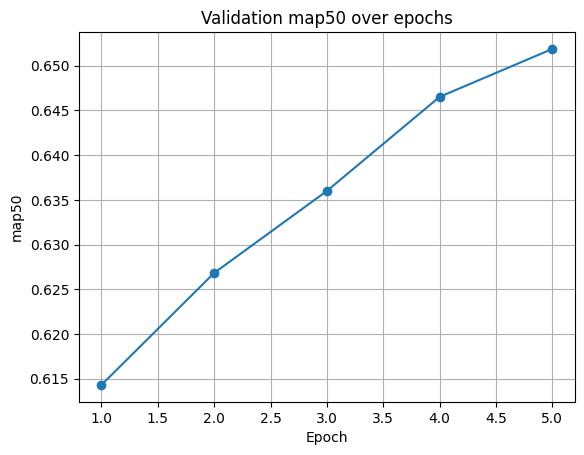

In [28]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], marker="o")
plt.title("Validation map50 over epochs")
plt.xlabel("Epoch")
plt.ylabel("map50")
plt.grid(True)
plt.show()

La map50 augmente progressivement sur les 5 époques, ce qui montre une convergence rapide du modèle.

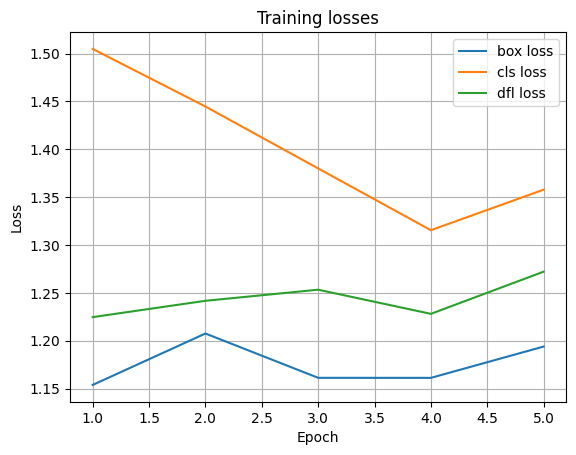

In [29]:
plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="box loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="cls loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="dfl loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses")
plt.legend()
plt.grid(True)
plt.show()

Le graphique ci-dessus présente l’évolution des trois pertes principales du modèle YOLOv8n :
- **box loss** (localisation des bounding boxes),
- **cls loss** (classification des objets),
- **dfl loss** (distribution focal loss, liée à la qualité de la précision des boîtes).

On observe que :

- La **cls_loss** diminue nettement entre l’epoch 1 et 4, ce qui indique que le modèle apprend à mieux classifier les objets.
- La **box_loss** reste globalement stable avec une légère tendance à la baisse, ce qui montre une amélioration de la localisation.
- La **dfl_loss** est relativement stable, ce qui est attendu sur un petit dataset comme coco128.

Il n’y a pas de signe d’**instabilité** ni de **divergence**, ce qui confirme que l’entraînement est sain et que l’optimiseur converge comme prévu.

3. Affichage de Precision & Recall curves

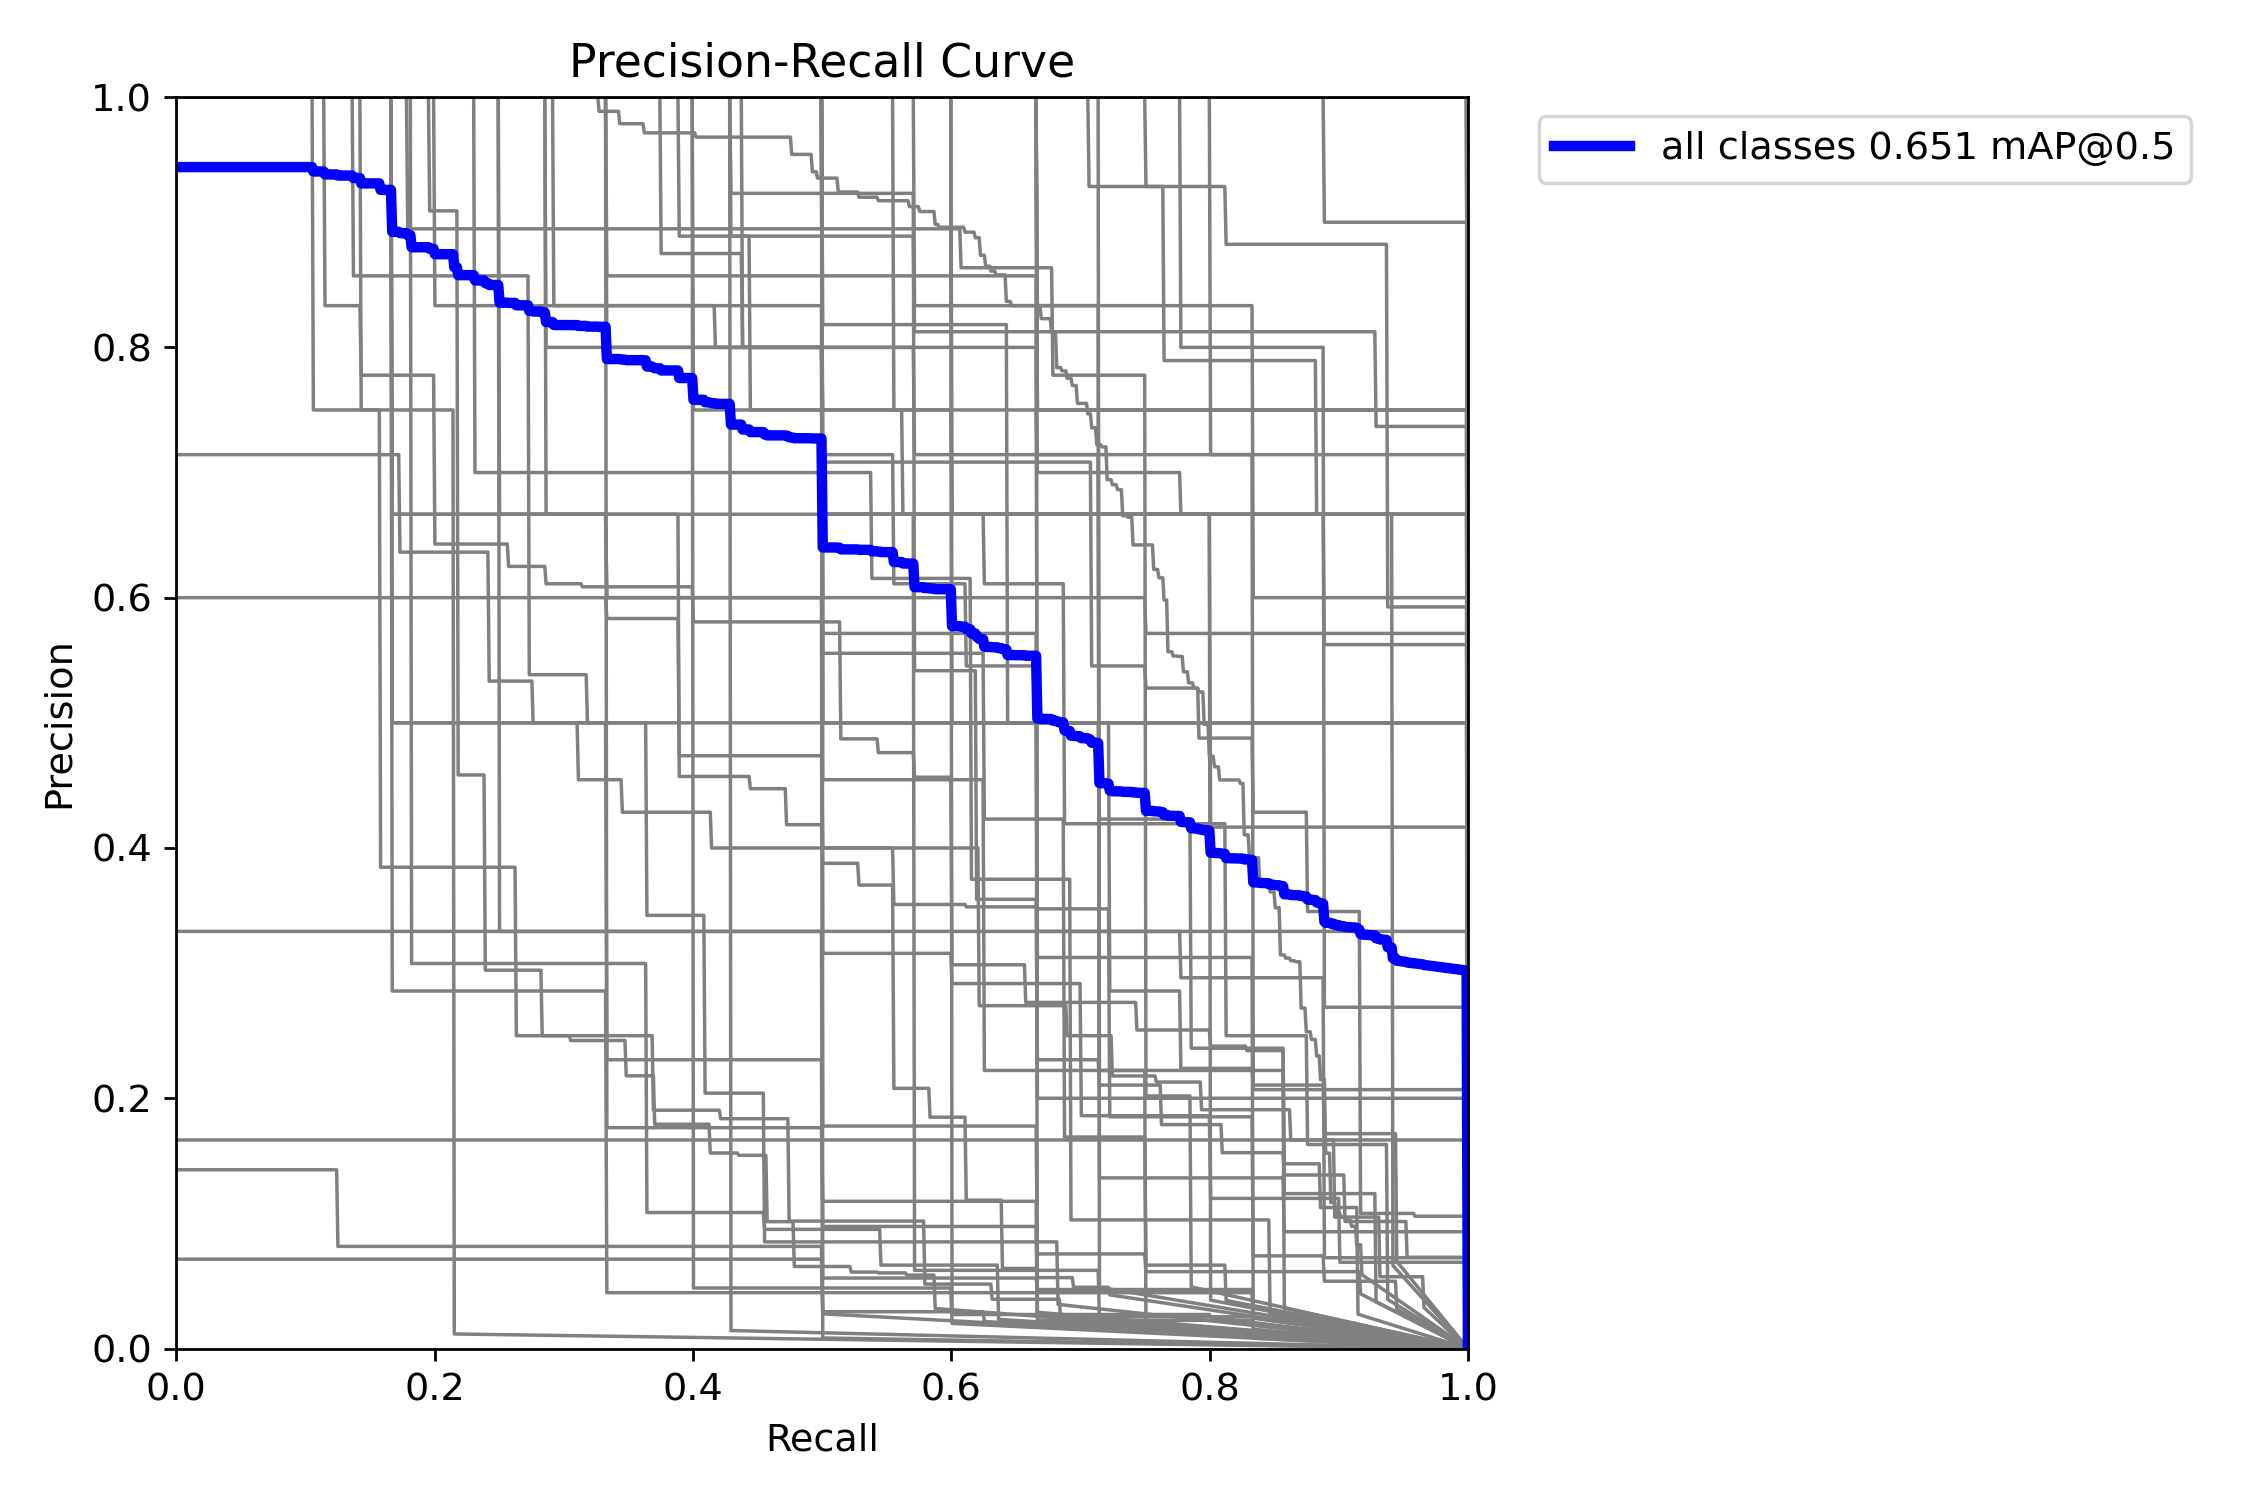

In [34]:
from IPython.display import Image, display

display(Image("outputs/train/BoxPR_curve.png"))

La courbe Precision–Recall montre la performance du modèle sur l’ensemble des classes du dataset.  
On observe que :

- Pour des niveaux de rappel faibles (< 0.4), la précision est très élevée (≈ 0.9).
- Lorsque le rappel augmente, la précision diminue progressivement, ce qui est typique des petits modèles comme YOLOv8n sur des datasets limités.
- L’aire sous la courbe correspond à la map50 (≈ 0.65 dans notre cas), ce qui confirme les résultats observés dans les métriques finales.

Cette courbe montre que le modèle est **prudent** : il fait peu de fausses détections (bonne précision), mais ne détecte pas tous les objets (rappel modéré).


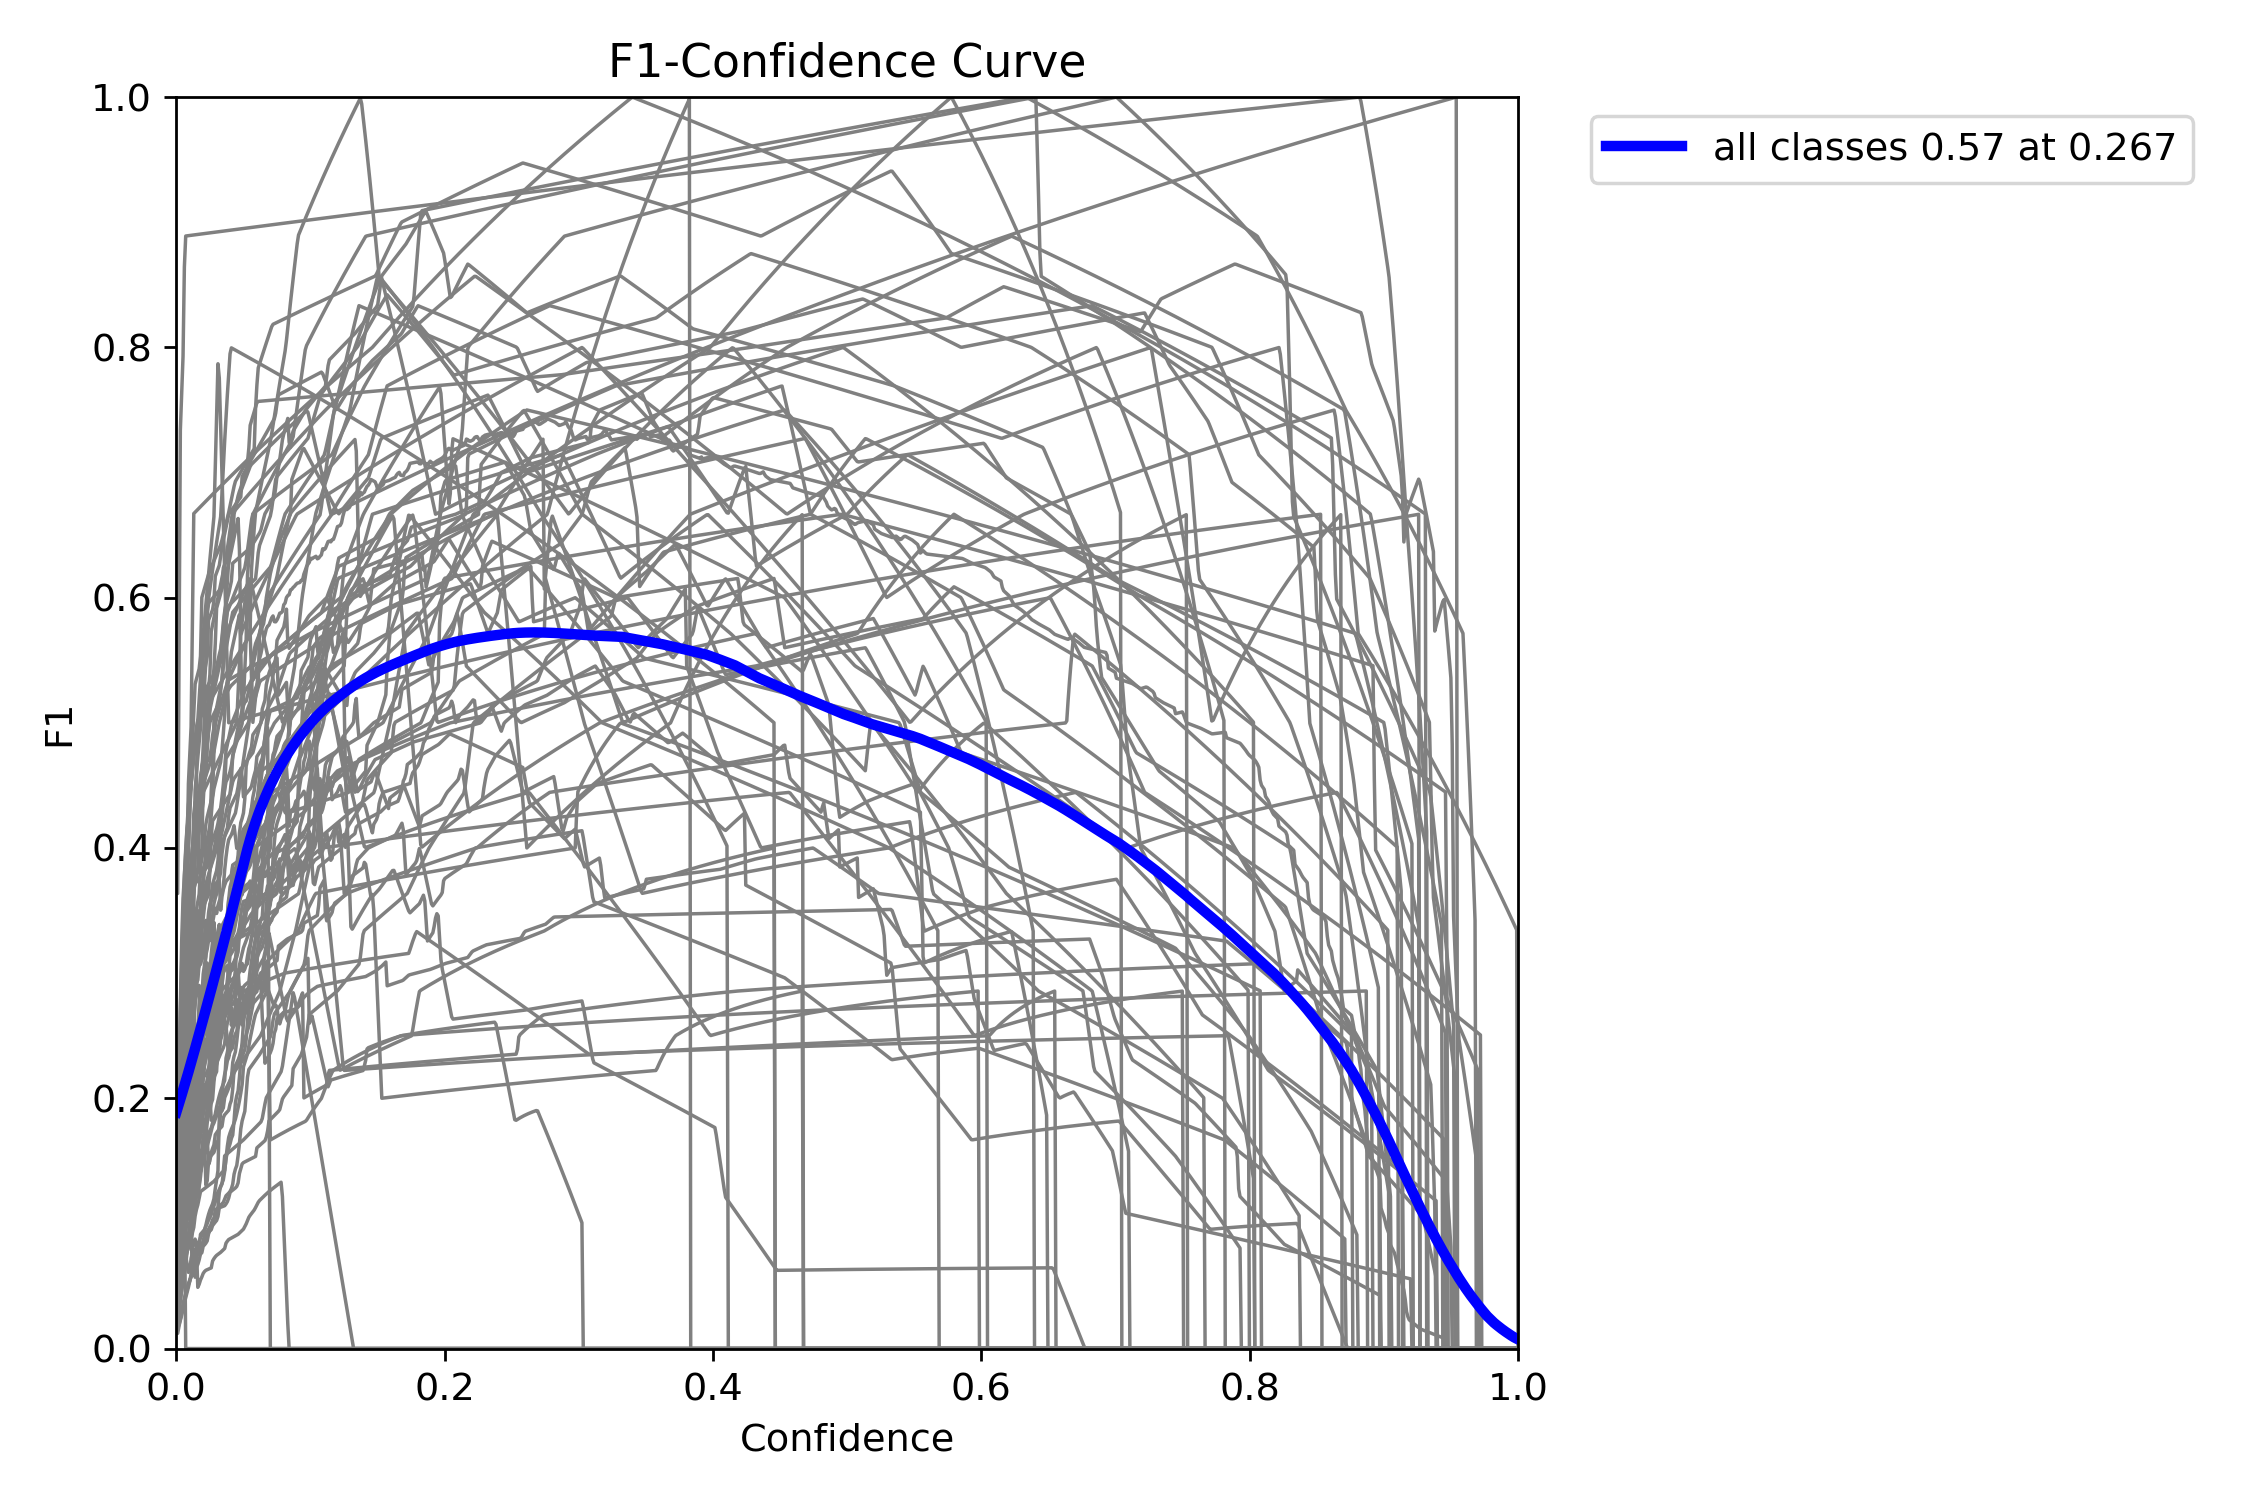

In [35]:
display(Image("outputs/train/BoxF1_curve.png"))

La courbe F1 en fonction du seuil de confiance montre que :

- Le score F1 maximal (~0.57) est atteint pour un seuil de confiance autour de **0.26**.
- Pour des confiances trop basses, le modèle génère de nombreuses prédictions (donc plus de faux positifs) → F1 faible.
- Pour des confiances trop hautes (> 0.6), le modèle devient trop strict → rappel chute rapidement → F1 baisse.

Cette courbe est utile pour choisir un **seuil de détection optimal** dans un pipeline réel.  
Dans notre cas, un seuil autour de **0.25–0.30** maximise l’équilibre entre précision et rappel.


4. Affichage de la matrix confusion

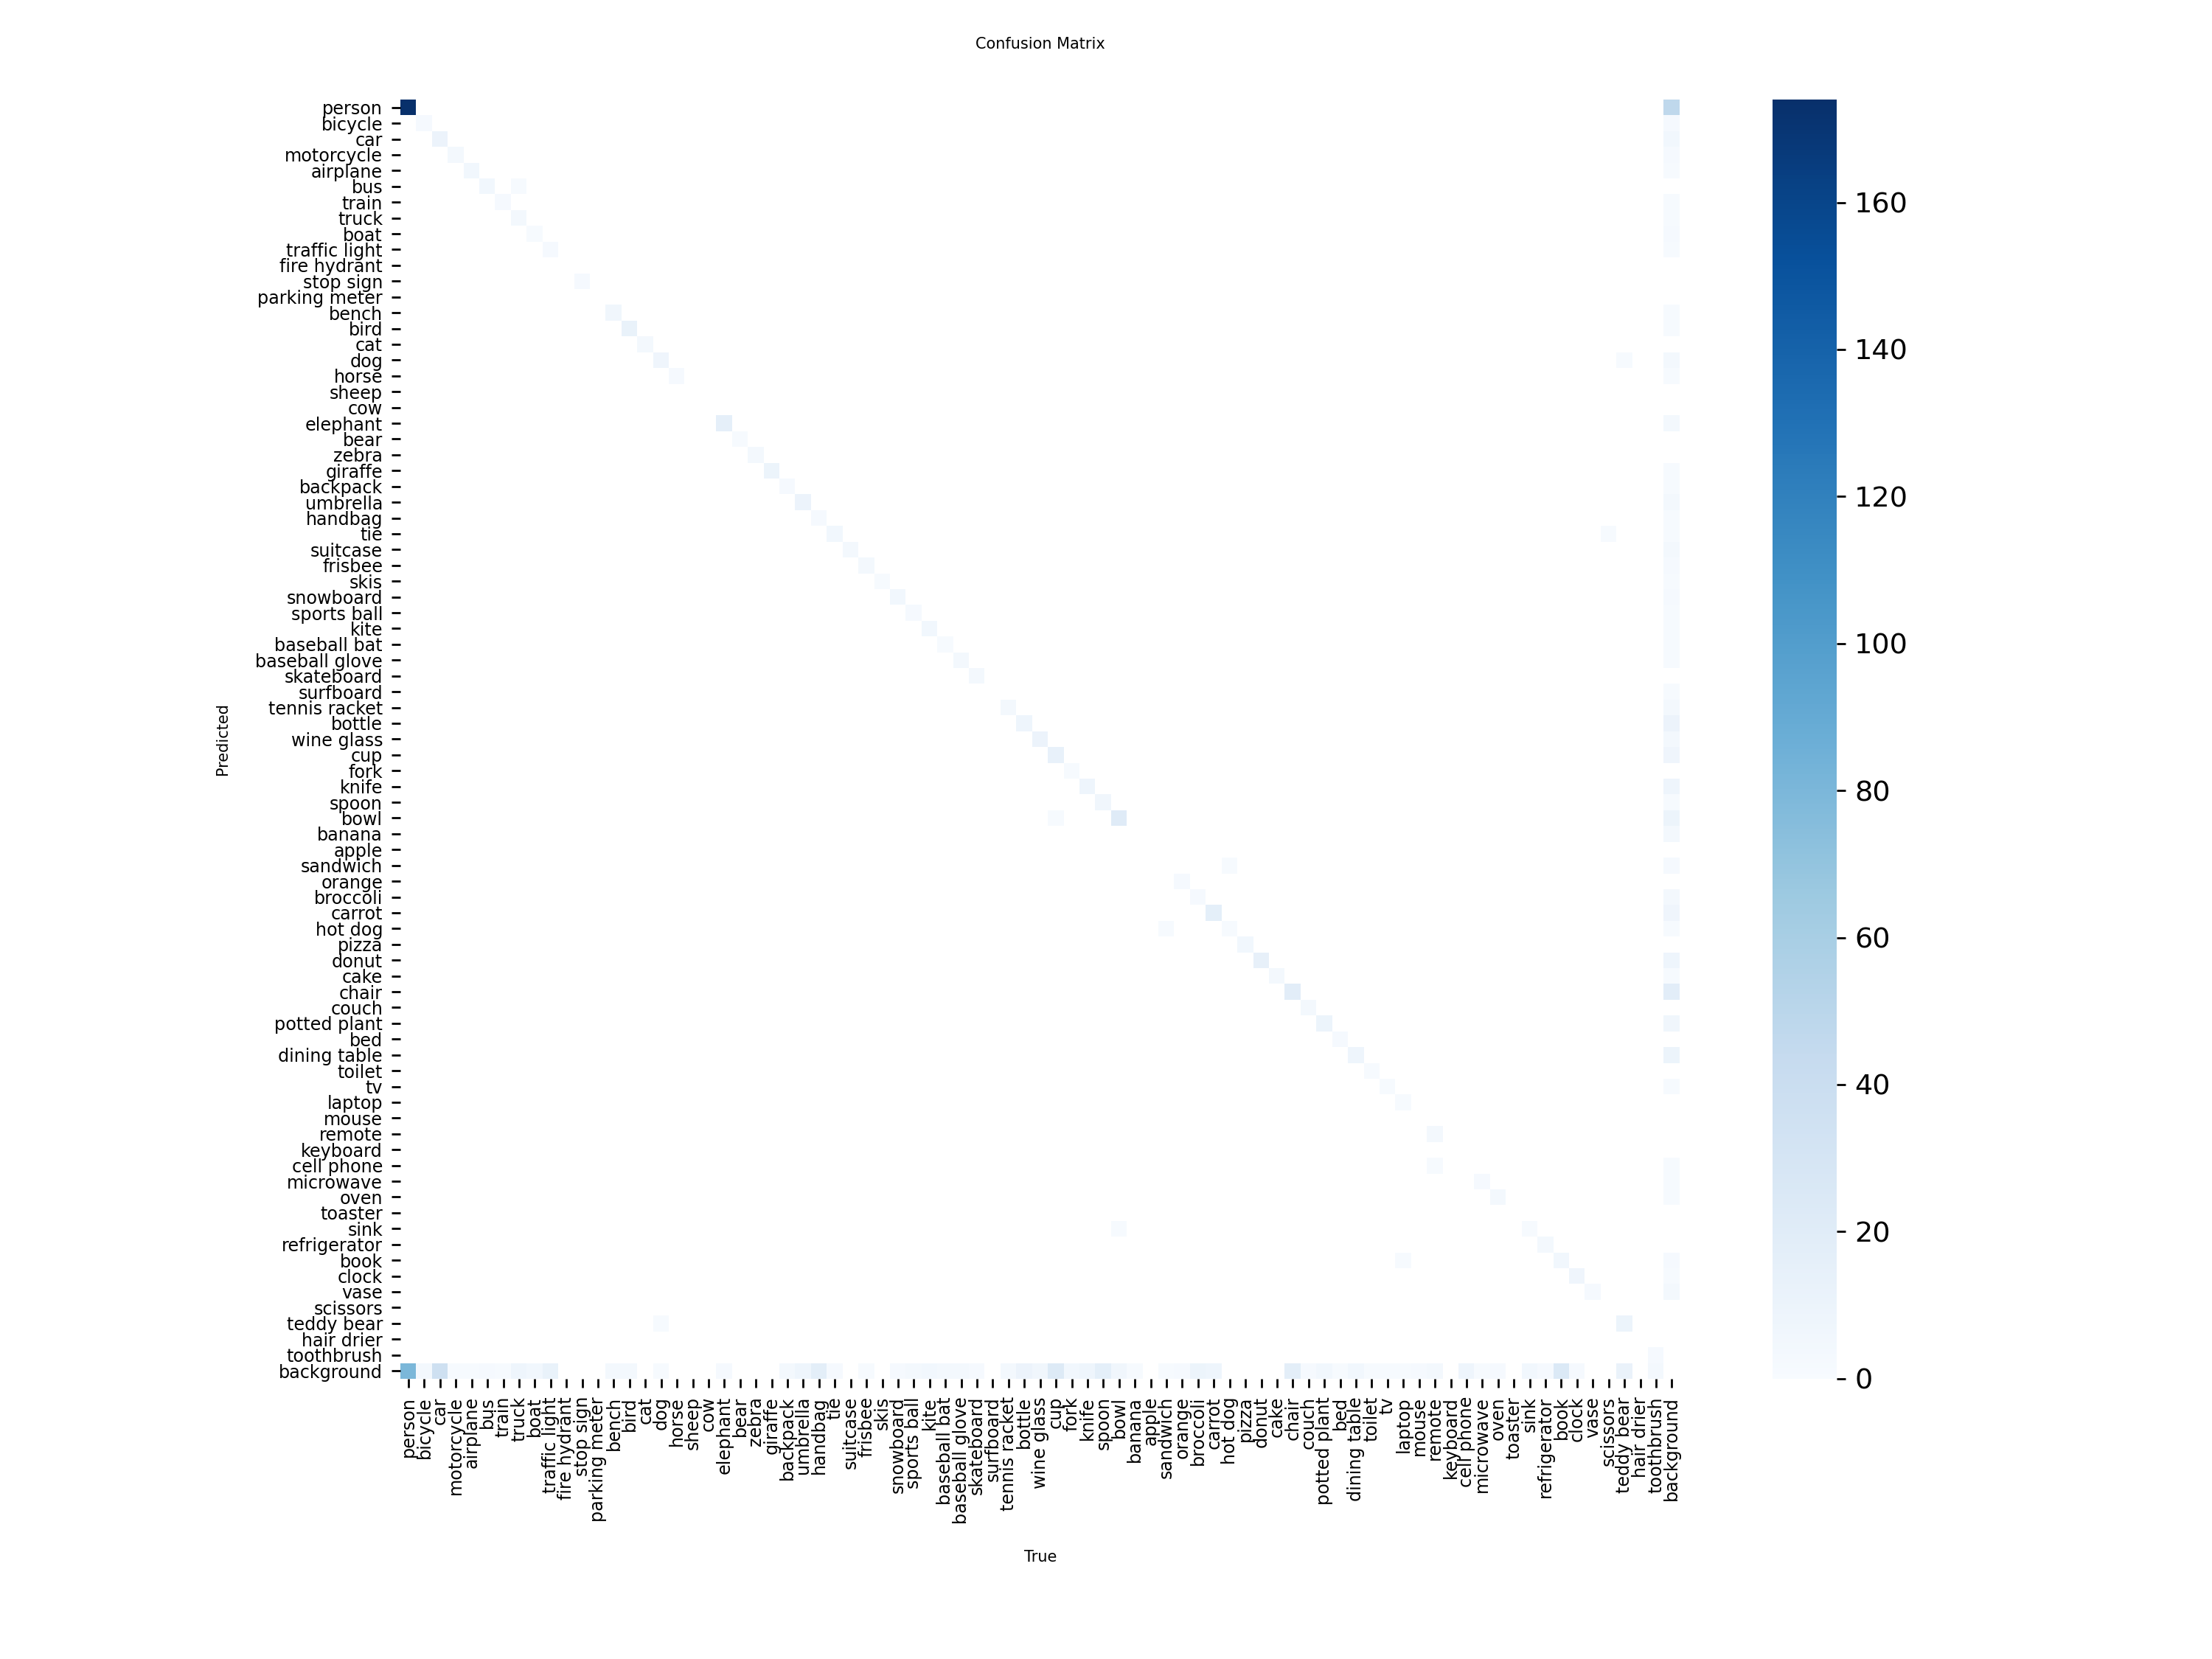

In [37]:
display(Image("outputs/train/confusion_matrix.png"))

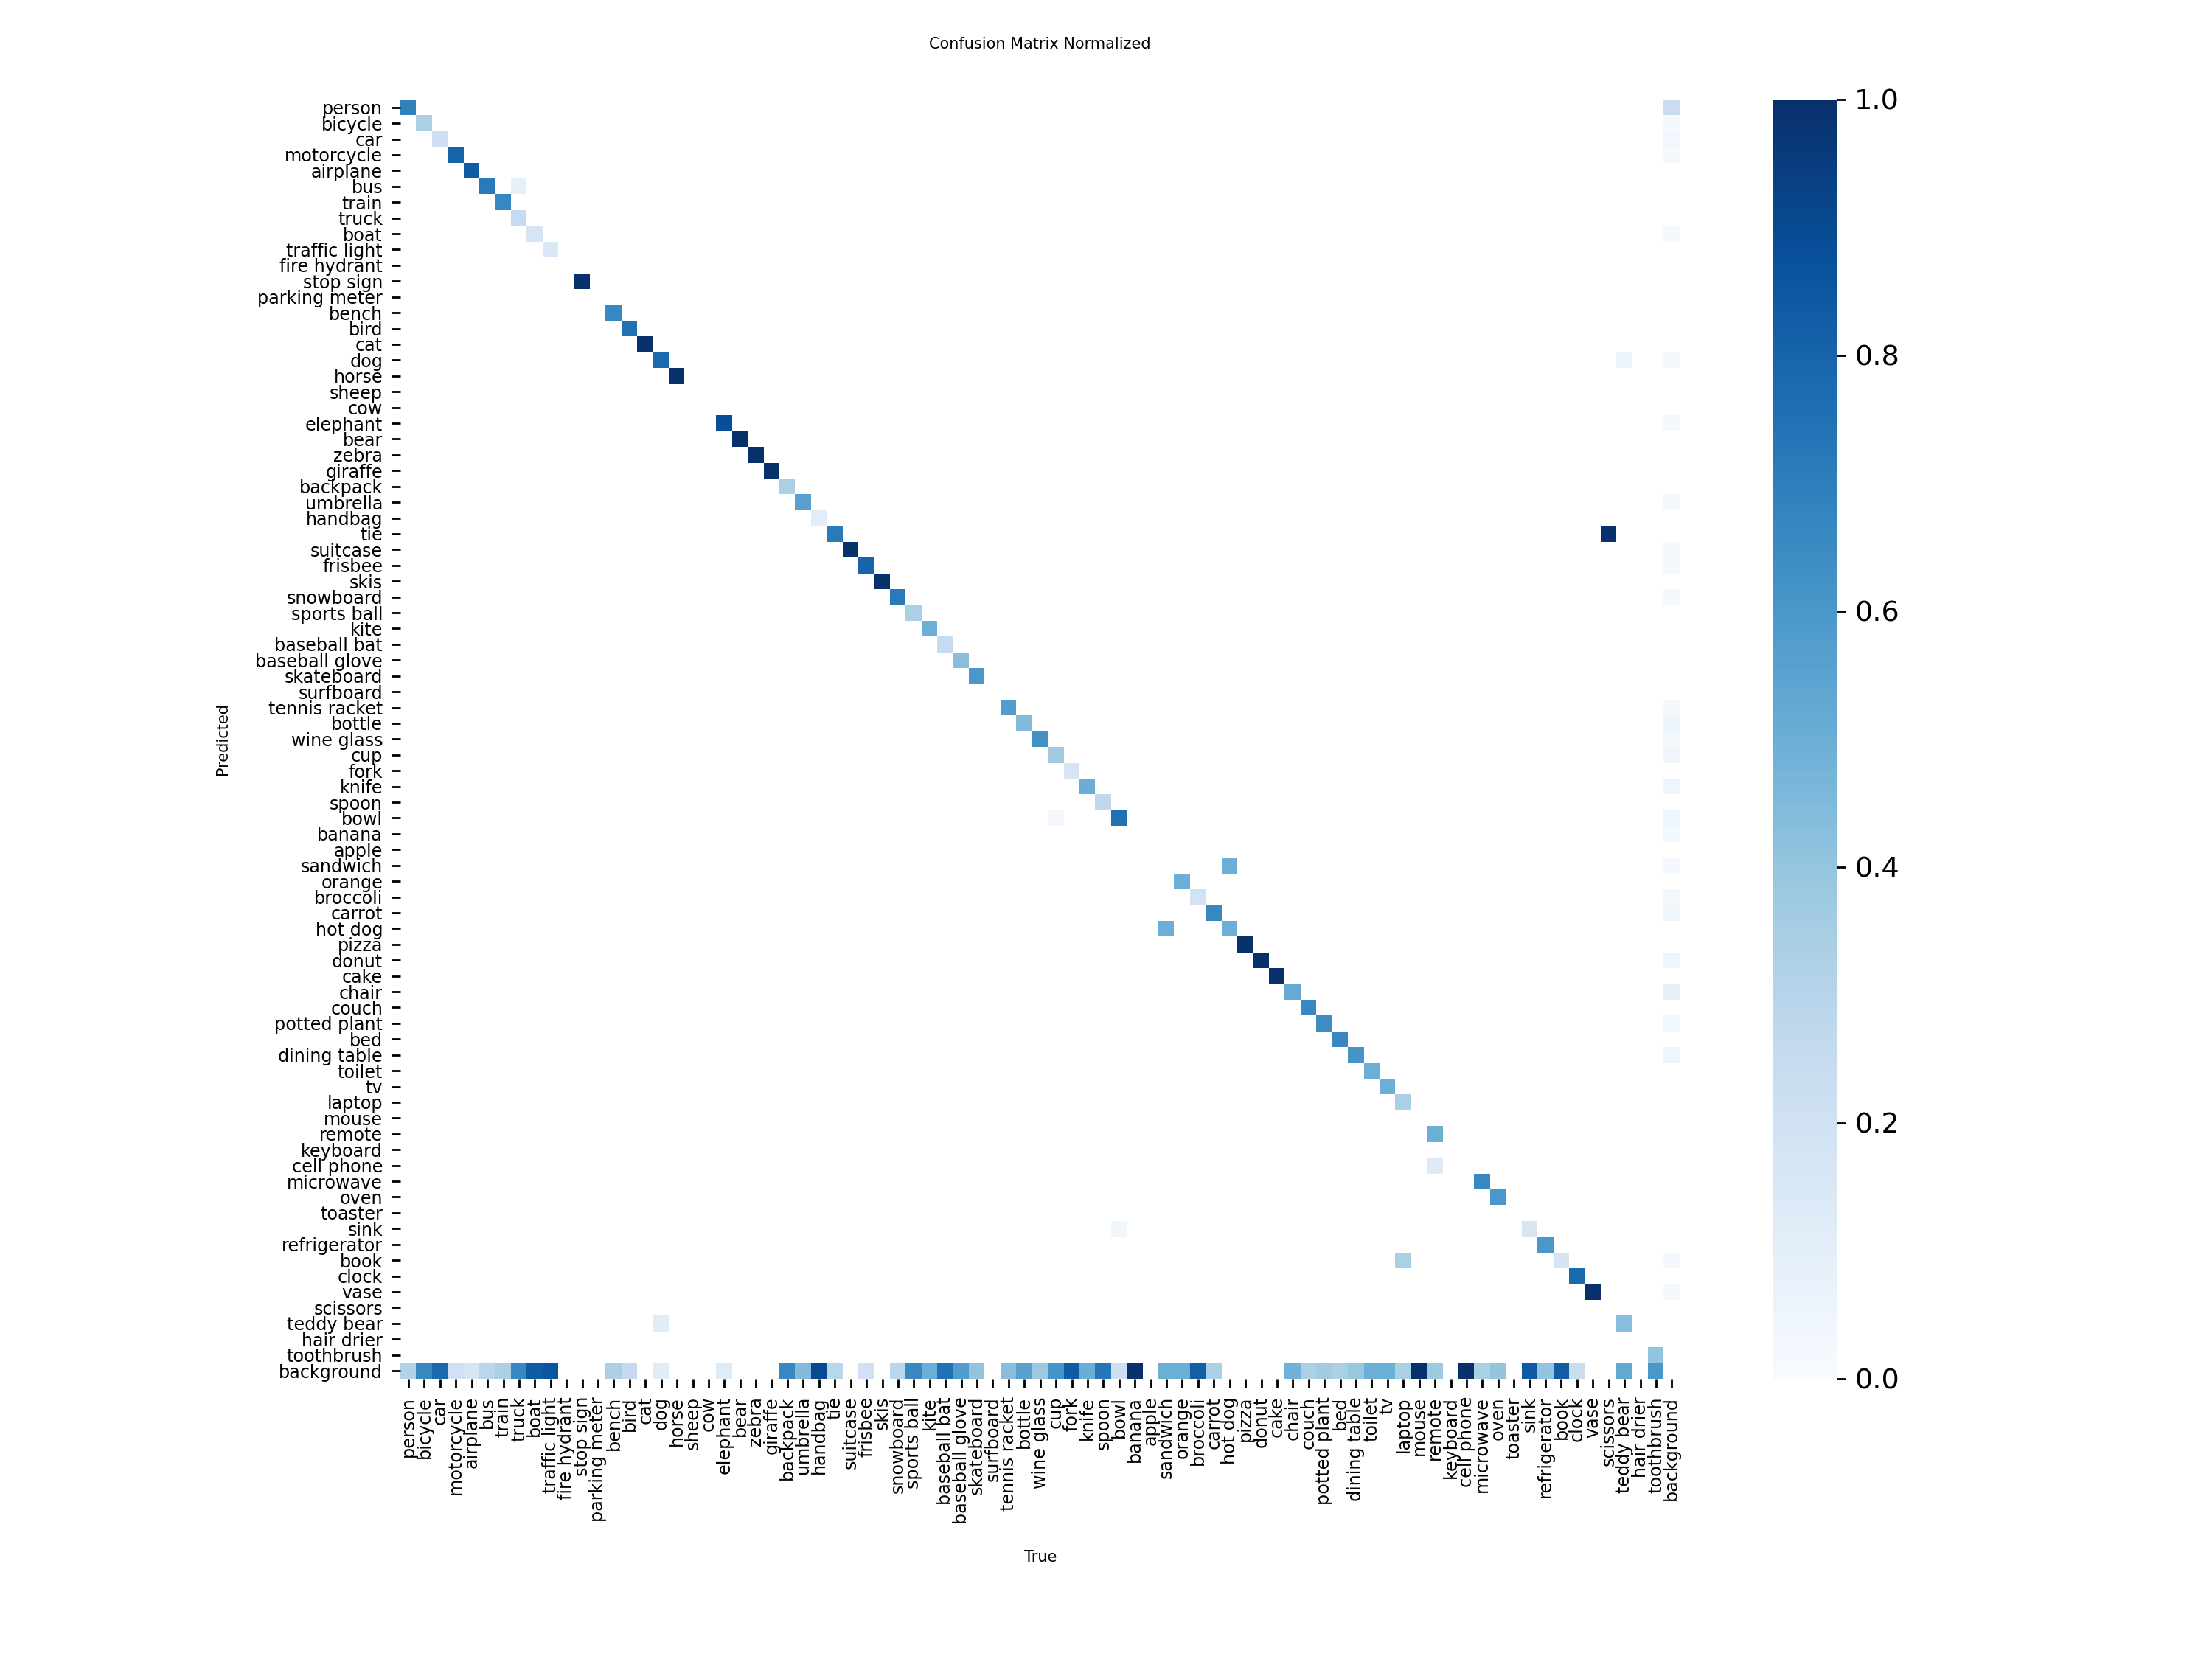

In [38]:
display(Image("outputs/train/confusion_matrix_normalized.png"))

Les matrices de confusion ci-dessus fournissent une analyse détaillée de la performance du modèle YOLOv8n sur les 80 classes du dataset COCO.

#### Raw Confusion Matrix
La matrice brute montre le nombre total de prédictions correctes et incorrectes pour chaque classe.  
On observe que :

- Les classes les plus représentées dans coco128, comme **person**, accumulent naturellement davantage de détections correctes.
- La diagonale est nettement marquée, indiquant que le modèle identifie correctement la majorité des objets détectés.
- Les confusions hors diagonale restent faibles, ce qui montre que le modèle ne mélange pas fortement les classes entre elles.

Cependant, la matrice brute est fortement influencée par la fréquence des classes : une classe rare peut sembler bien ou mal performante simplement parce qu’elle apparaît très peu.

#### Normalized Confusion Matrix
La matrice normalisée permet de contourner ce biais en représentant, pour chaque classe, le **pourcentage** de prédictions correctes.  
Elle montre que :

- Les classes fréquentes (ex. *person*, *car*, *dog*) affichent des taux de détection élevés, proches de **1.0**.
- Les classes rares voient leur performance chuter — parfois à 0 — car coco128 contient très peu d’exemples pour certaines d’entre elles (*hair drier*, *toaster*, *bear*, etc.).
- Quelques confusions existent entre classes visuellement similaires (ex. *cup* vs *bowl*, *bicycle* vs *motorcycle*), ce qui est attendu pour un petit modèle comme YOLOv8n.

#### Conclusion
La comparaison des deux matrices montre que :

1. **YOLOv8n performe très bien sur les classes fréquentes**, même avec seulement 128 images d’entraînement.  
2. **Les classes rares sont difficiles à détecter**, faute de données représentatives dans coco128.  
3. **Le modèle reste stable et cohérent** : peu de confusions importantes, comportement attendu sur un small dataset.

Ces résultats confirment que le modèle apprend efficacement les classes dominantes mais reste limité par la taille du dataset pour les classes peu représentées.


5. Affichage images qualitatives (batch preds)

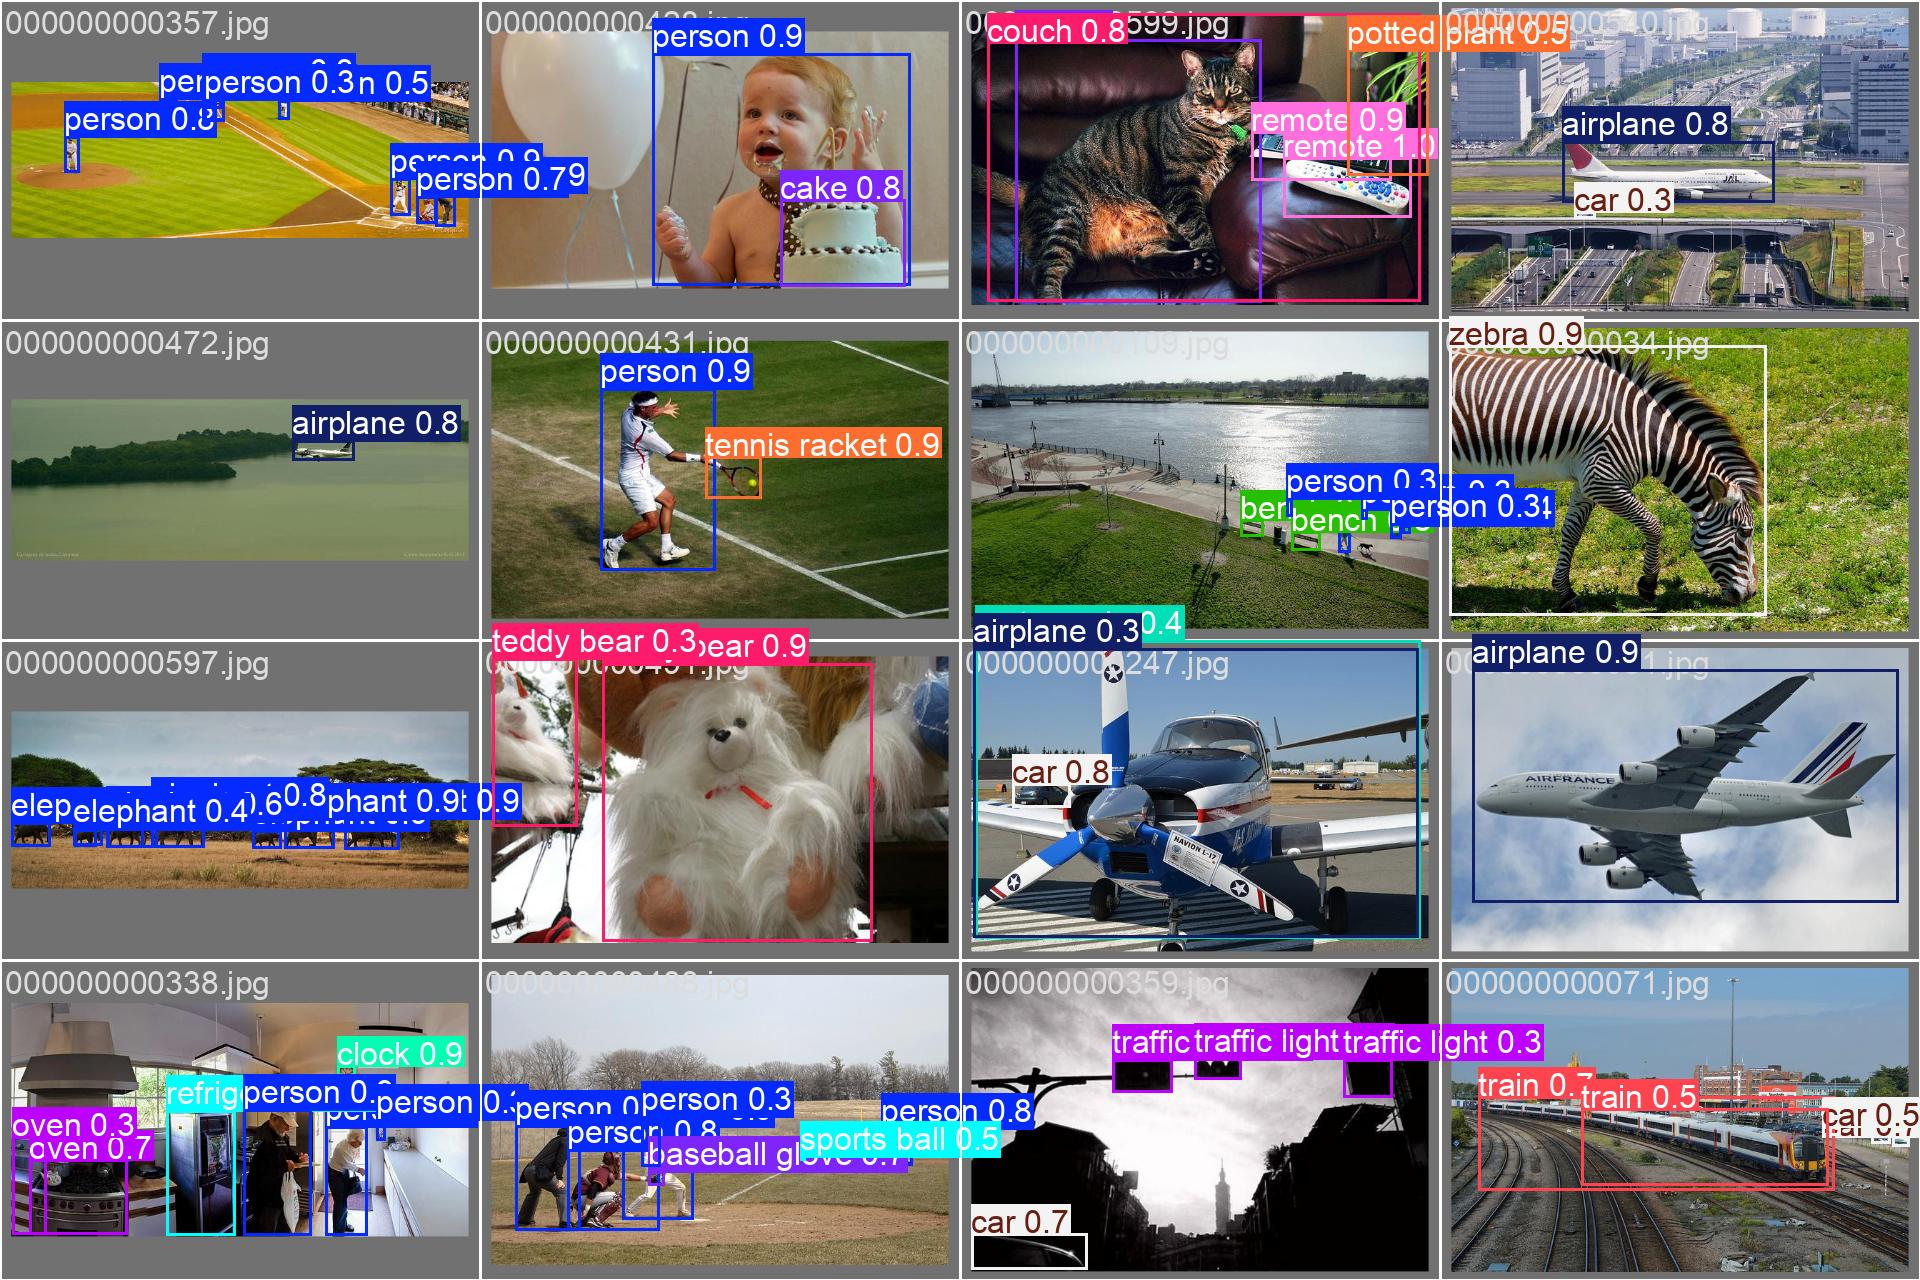

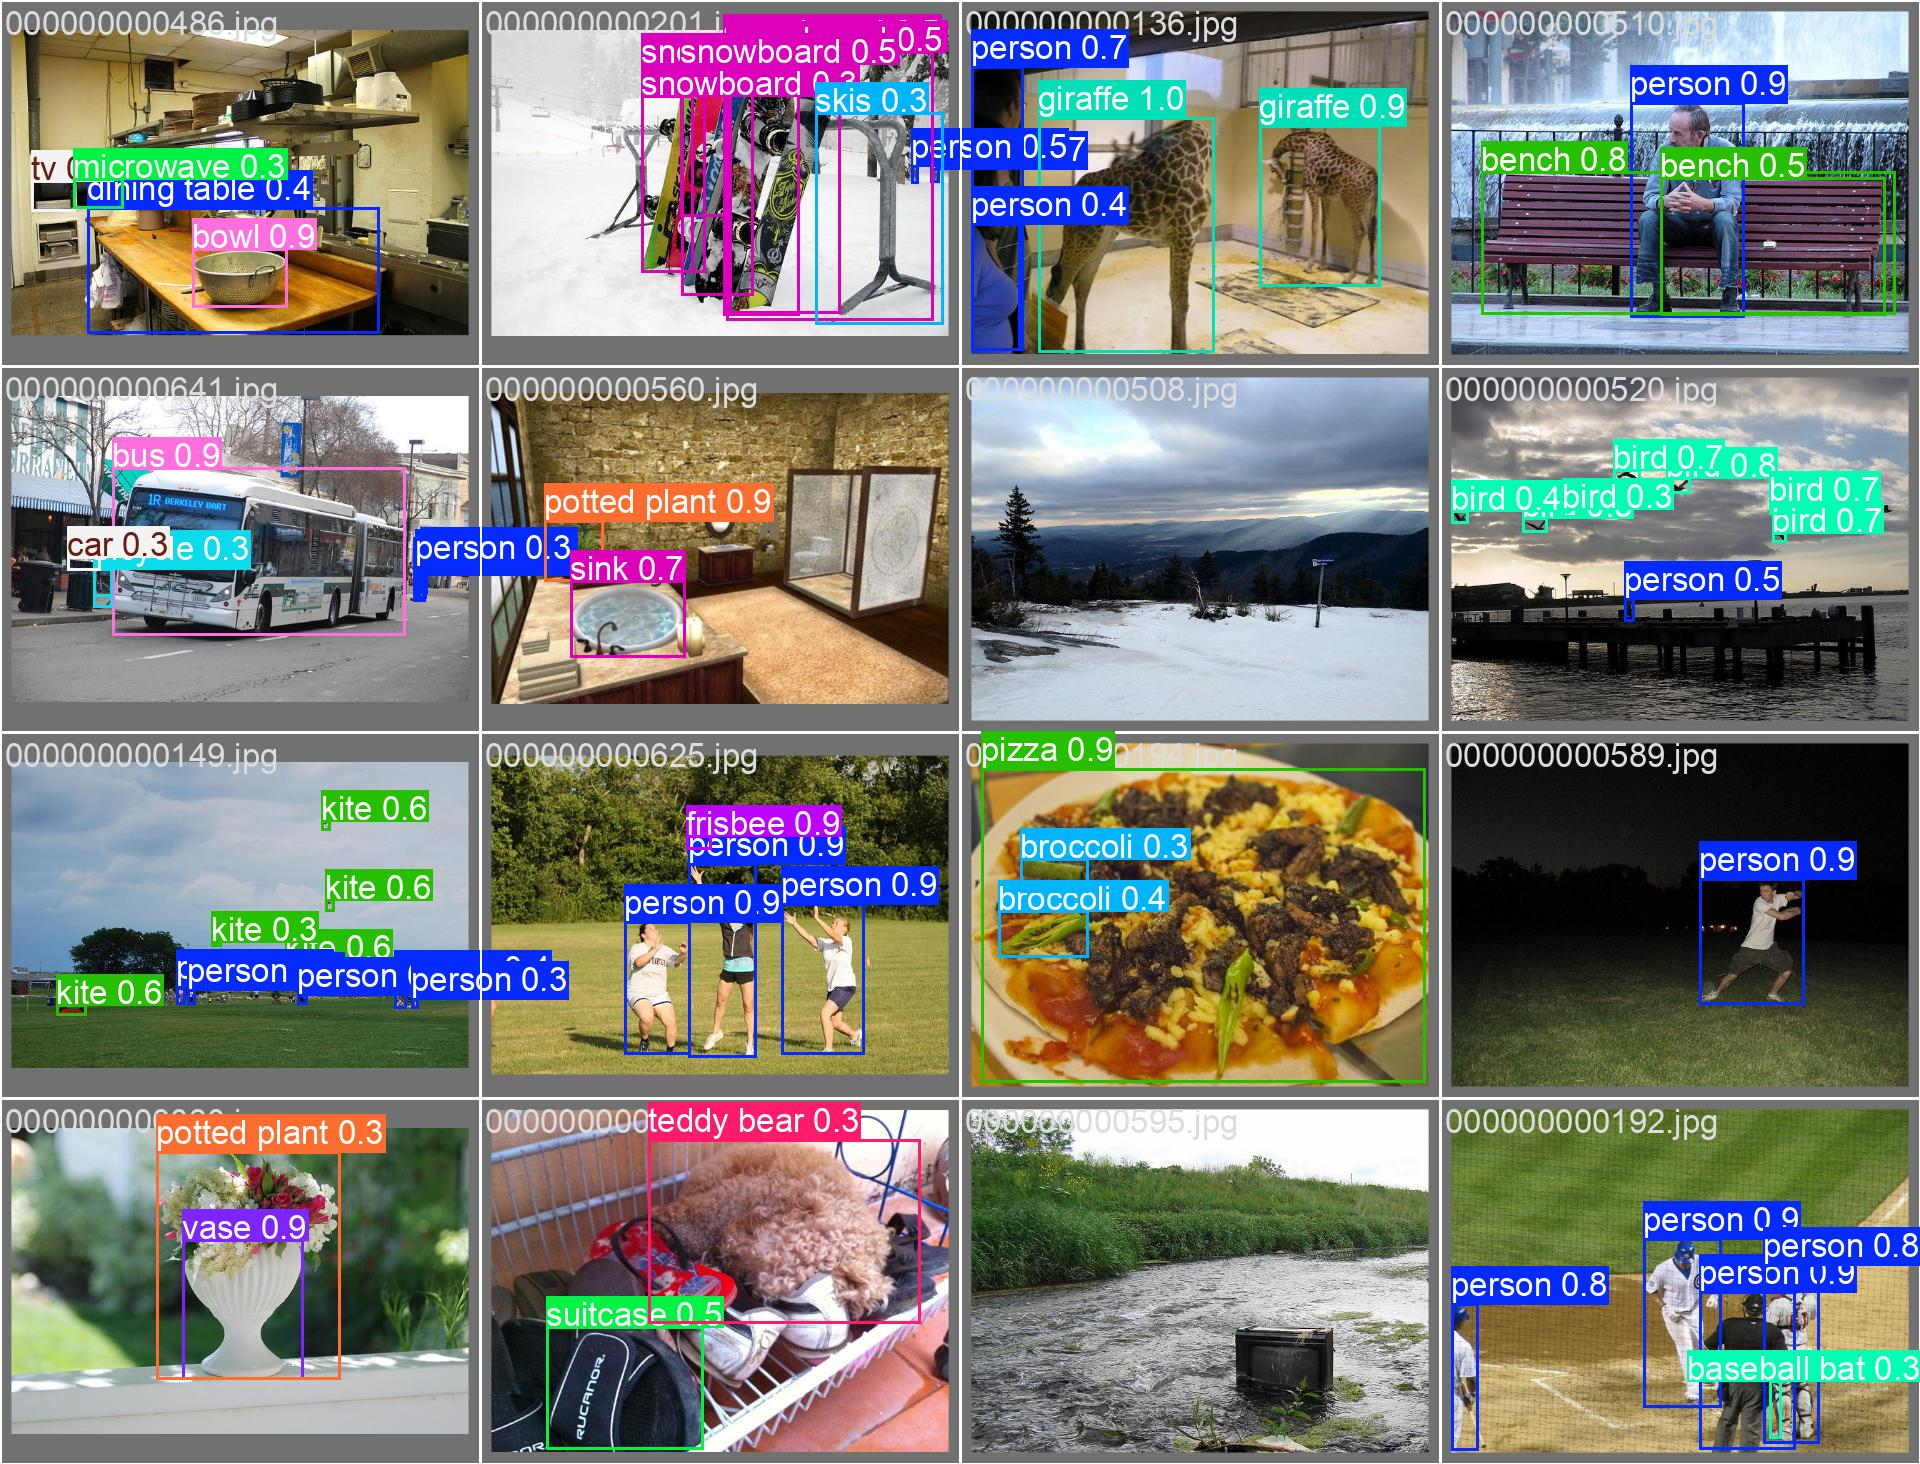

In [39]:
display(Image("outputs/train/val_batch0_pred.jpg"))
display(Image("outputs/train/val_batch1_pred.jpg"))

Les images ci-dessus présentent un échantillon des prédictions réalisées par le modèle YOLOv8n sur le jeu de validation.  
Plusieurs tendances importantes peuvent être observées :

- Le modèle détecte correctement les objets dominants dans les scènes : *person*, *car*, *airplane*, *dog*, *cat*, *bench*, etc.
- Les objets de grande taille ou bien contrastés sont identifiés avec des scores de confiance élevés (souvent > 0.8).
- La localisation des boîtes est globalement précise, même dans des scènes complexes ou avec plusieurs objets.
- Certains objets de petite taille ou partiellement visibles sont manqués ou détectés avec une faible confiance (ex. *sports ball*, *bird*, *clock*).
- Le modèle présente parfois des erreurs mineures de classification (ex. *teddy bear* vs *doll*, *potted plant* vs *vase*).
- Dans les images où les objets sont très nombreux (ex. scènes urbaines, superpositions), les détections restent correctes mais moins complètes.

#### Interprétation
Ces résultats qualitatifs confirment les observations issues des métriques :
- Le modèle est **fiable sur les classes fréquentes** et bien représentées dans coco128.
- Les confusions et manques concernent principalement des objets **de petite taille** ou **peu représentés dans le dataset**.
- Malgré seulement 5 époques d’entraînement sur un dataset de 128 images, les performances sont déjà solides.

Les prédictions qualitatives montrent que YOLOv8n parvient à généraliser correctement et à détecter la majorité des objets visibles, tout en illustrant les limites attendues sur les classes rares et les petites instances.


# M4 — Ablation Studies & Analysis

Pour évaluer l’impact de différents hyperparamètres sur les performances du modèle YOLOv8n entraîné sur COCO128, nous avons réalisé deux ablations :

1. **Ablation 1 : Learning rate réduit (lr0 = 0.001)**  
2. **Ablation 2 : Image size réduite (imgsz = 320 au lieu de 640)**  

#### Ablation 1 – Learning Rate réduit

In [46]:
model = YOLO("yolov8n.pt")
results_lr = model.train(
    data="coco128.yaml",
    epochs=5,
    imgsz=640,
    lr0=0.001,
    batch=16,
    name="yolo_lr0001"
)

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_lr0001, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrain

#### Ablation 2 – Image size réduit

In [48]:
model = YOLO("yolov8n.pt")
results_imgsz = model.train(
    data="coco128.yaml",
    epochs=5,
    imgsz=320,
    lr0=0.01,
    batch=16,
    name="yolo_imgsz320"
)

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_imgsz320, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrai

#### Tableau comparatif

In [67]:
baseline = metrics  # chargé depuis metrics.json

# Récupération correcte dans Ultralytics >=8.3.x
lr = results_lr.results_dict
imgsz = results_imgsz.results_dict

In [65]:
import pandas as pd

df_compare = pd.DataFrame([
    [
        "Baseline",
        baseline["metrics"]["map50"],
        baseline["metrics"]["map"],
        baseline["metrics"]["precision"],
        baseline["metrics"]["recall"]

    ],
    [
         "LR=0.001",
        lr["metrics/mAP50(B)"],
        lr["metrics/mAP50-95(B)"],
        lr["metrics/precision(B)"],
        lr["metrics/recall(B)"]
    ],
    [
        "imgsz=320",
        imgsz["metrics/mAP50(B)"],
        imgsz["metrics/mAP50-95(B)"],
        imgsz["metrics/precision(B)"],
        imgsz["metrics/recall(B)"]
    ]
], columns=["Experiment", "mAP@50", "mAP@50-95", "Precision", "Recall"])

df_compare

,Experiment,mAP@50,mAP@50-95,Precision,Recall
0,Baseline,0.652949,0.486578,0.674835,0.586119
1,LR=0.001,0.648699,0.484115,0.677985,0.566870
2,imgsz=320,0.524742,0.387495,0.614737,0.495317


#### 1. Effet du Learning Rate (LR=0.001)

La réduction du learning rate entraîne :
- une très légère baisse du mAP@50 (-0.0042),
- une baisse du mAP@50-95 similaire,
- une précision quasi identique,
- une baisse du rappel.

Cela s’explique par le fait qu’un learning rate plus faible stabilise l’optimisation, mais sur un dataset aussi petit que COCO128, le modèle ne bénéficie pas pleinement de cette stabilité dans seulement 5 epochs. Le LR plus faible rend l’apprentissage moins agressif, ce qui limite la convergence rapide.

 **Conclusion** : effet modéré, aucune amélioration notable.

---

####  2. Effet de la réduction de la taille d’image (imgsz=320)

Ici, on observe une chute significative :
- map50 passe de **0.65 → 0.52** (-13%),
- map passe de **0.49 → 0.39**,
- précision et rappel diminuent clairement.

Une image de taille 320 contient deux fois moins de pixels qu’une image 640 × 640.  
Cela réduit fortement :
- la qualité des détails visuels,
- la capacité du modèle à détecter les petits objets,
- la précision des bounding boxes.

 **Conclusion** : la réduction de résolution diminue fortement les performances, même pour un modèle léger comme YOLOv8n.

---

### Synthèse des ablations

- Le **learning rate** influence légèrement la stabilité mais ne modifie pas significativement la performance globale dans ce contexte.
- La **taille d’image** est un facteur critique : diminuer la résolution réduit fortement la qualité de détection.
- Ces observations sont cohérentes avec la littérature :  
  les modèles YOLO sont très sensibles à la résolution d’entrée, surtout sur les objets petits et les datasets à faible variabilité.

### Conclusion

Les deux ablations montrent que :
- **imgsz est l’hyperparamètre le plus déterminant**,  
- **lr0 n’a qu’un impact faible sur un petit dataset**,  
- la baseline est bien choisie et constitue un point de départ stable.


## M5 — Reporting & Final Delivery

Pour conclure, même avec un dataset minimaliste comme COCO128, YOLOv8n parvient à atteindre des performances raisonnables.  
Les expériences montrent clairement :

- la sensibilité du modèle à la résolution d’image  
- l’intérêt d’un pipeline structuré pour analyser les hyperparamètres  
- la nécessité de datasets plus grands pour atteindre une performance robuste

Ce projet démontre la capacité à implémenter, entraîner, analyser et documenter un modèle de détection moderne d'objets.